There's been some trouble with the model learning from the xrd patterns of the deepmind data. This may be because there is somthing wrong with those xrd patterns. 

The first step of the pipeline for making the deepmind data was generating the xrd patterns. The script is below 

In [14]:
from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator

import pandas as pd

import sys
import os
import numpy as np
#read in the worker number 
try: 
    worker_num = int(sys.argv[1])
except: 
    worker_num = 0

num_splits = 100

print("worker_num", worker_num)
print("num_splits", num_splits)

try: 
    print('using data_dir', str(sys.argv[2]))
    data_dir = str(sys.argv[2])
except:
    print("using default data_dir /home/gridsan/tmackey/materials_discovery/data/mp_20_for_validation/")
    data_dir = '/home/gridsan/tmackey/materials_discovery/data/mp_20_for_validation/'


#load in the data 
train_df = pd.read_csv(data_dir + 'train.csv')
test_df = pd.read_csv(data_dir + 'test.csv')
val_df = pd.read_csv(data_dir + 'val.csv')

# Initialize the XRDCalculator with a wavelength of CuKa (1.54060 Å)
xrd_calculator = XRDCalculator(wavelength='CuKa')
from tqdm.auto import tqdm
tqdm.pandas()

def get_xrd_information(crystal_str):
    try: 
        crystal = Structure.from_str(crystal_str, fmt='cif')
    except:
        crystal = None

    try:  
        xrd = xrd_calculator.get_pattern(crystal)
    except: 
        xrd = None

    try: 
        x = xrd.x.tolist()
        y = xrd.y.tolist()
    except:
        x = None
        y = None

    try: 
        atomic_species = [Element(specie).Z for specie in crystal.species]
    except: 
        atomic_species = None

    return [xrd, x, y, atomic_species]

data_frames = {"train": train_df, "test": test_df, "val": val_df}

for name, df in data_frames.items():
    
    chunk_size = np.ceil(len(df)/num_splits)
    
    start_index = int(worker_num*chunk_size)
    end_index = int(min(start_index + chunk_size, len(df))) #prevents end index > len(df)
    
    print("start_index", start_index)
    print("end_index", end_index)

    sub_df = df.iloc[start_index:end_index].copy()
    sub_crystals = sub_df['cif'].progress_apply(get_xrd_information)
    sub_df['xrd'] = sub_crystals.progress_apply(lambda x: x[0])
    sub_df['xrd_peak_locations'] = sub_crystals.progress_apply(lambda x: x[1])
    sub_df['xrd_peak_intensities'] = sub_crystals.progress_apply(lambda x: x[2])
    sub_df['atomic_numbers'] = sub_crystals.progress_apply(lambda x: x[3])

    #save the csv
    sub_df.to_csv(data_dir + f'{name}_xrd_{worker_num}.csv', index=False)

worker_num 0
num_splits 100
using default data_dir /home/gridsan/tmackey/materials_discovery/data/mp_20_for_validation/
start_index 0
end_index 272


  0%|          | 0/272 [00:00<?, ?it/s]

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


  0%|          | 0/272 [00:00<?, ?it/s]

  0%|          | 0/272 [00:00<?, ?it/s]

...

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


  0%|          | 0/44 [00:00<?, ?it/s]

  0%|          | 0/44 [00:00<?, ?it/s]

  0%|          | 0/44 [00:00<?, ?it/s]

  0%|          | 0/44 [00:00<?, ?it/s]

Let's take a look at the results from the 0 worker and compare to the original

In [2]:
import pandas as pd
import numpy as np

In [3]:
data_dir = '/home/gridsan/tmackey/materials_discovery/data/mp_20_for_validation/'

In [4]:
train_xrd_0 = pd.read_csv(data_dir + 'train_xrd_0.csv')

In [13]:
list(train_df['xrd_peak_locations'][:len(train_xrd_0)]) == list(train_xrd_0['xrd_peak_locations'])

True

So it looks like the first worker did a good job of generating patterns. But errors could have been introduced when the data was merged or when other workers were used. 

In [16]:
import pandas as pd
import numpy as np
from tqdm import tqdm

#assuming all of the data was stored as .pt dictionaries of string keys and graph values
num_workers = 100
dataset_names =  ['train', 'test', 'val']
data_source = "mp_20_dm"

data_dir = '/home/gridsan/tmackey/materials_discovery/data/mp_20_for_validation/'

for name in dataset_names:
    total_df = pd.DataFrame()
    for worker_num in tqdm(range(num_workers)):
        df = pd.read_csv(data_dir + f'{name}_xrd_{worker_num}.csv')
        #add df without using append
        total_df = pd.concat([total_df, df])
    total_df.to_csv(data_dir + f"{name}_xrd.csv", index=False)
    print(f"Saved {name} dataset")

100%|██████████| 100/100 [00:03<00:00, 26.14it/s]


Saved train dataset


100%|██████████| 100/100 [00:01<00:00, 62.37it/s]


Saved test dataset


100%|██████████| 100/100 [00:01<00:00, 86.36it/s]


Saved val dataset


In [20]:
#let's load back in the combined train_xrd dataset
train_xrd = pd.read_csv(data_dir + 'train_xrd.csv')
test_xrd = pd.read_csv(data_dir + 'test_xrd.csv')
val_xrd = pd.read_csv(data_dir + 'val_xrd.csv')

In [21]:
print(list(train_df['xrd_peak_locations']) == list(train_xrd['xrd_peak_locations']))
print(list(train_df['xrd_peak_intensities']) == list(train_xrd['xrd_peak_intensities']))
print(list(test_df['xrd_peak_locations']) == list(test_xrd['xrd_peak_locations']))
print(list(test_df['xrd_peak_intensities']) == list(test_xrd['xrd_peak_intensities']))
print(list(val_df['xrd_peak_locations']) == list(val_xrd['xrd_peak_locations']))
print(list(val_df['xrd_peak_intensities']) == list(val_xrd['xrd_peak_intensities']))

True
True
True
True
True
True


In [23]:
#just to make sure that the equality operation is working, make a faulty datasets
#by changing one entry in the train_xrd dataset
train_xrd_faulty = train_xrd.copy()
train_xrd_faulty['xrd_peak_locations'].iloc[0] = '[1,2,3]'
print(list(train_df['xrd_peak_locations']) == list(train_xrd_faulty['xrd_peak_locations']))

False


/tmp/ipykernel_4007481/1779883756.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_xrd_faulty['xrd_peak_locations'].iloc[0] = '[1,2,3]'


So it looks like the xrds aren't the issue. It might be the case that the compounds themselves are at fault. Let's see if they are all valid as determined by cdvae's smact validity checker. 

In [1]:
import torch

In [2]:
#start with the test data 
test_graphs_dm = torch.load('/home/gridsan/tmackey/cdvae/data/mp_20_dm/test.pt')
test_graphs_mp = torch.load('/home/gridsan/tmackey/cdvae/data/mp_20/test.pt')

In order to use CDVAE's smact validity, we need to load in a ton of stuff.

In [5]:
from collections import Counter
import argparse
import os
import json

import numpy as np
from pathlib import Path
from tqdm import tqdm
from p_tqdm import p_map
from scipy.stats import wasserstein_distance

from pymatgen.core.structure import Structure
from pymatgen.core.composition import Composition
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.structure_matcher import StructureMatcher
from matminer.featurizers.site.fingerprint import CrystalNNFingerprint
from matminer.featurizers.composition.composite import ElementProperty

from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
from pymatgen.io.cif import CifWriter

#added by Tsach


from eval_utils import (
    smact_validity, structure_validity, CompScaler, get_fp_pdist,
    load_config, load_data, get_crystals_list, prop_model_eval, compute_cov)


CrystalNNFP = CrystalNNFingerprint.from_preset("ops")
CompFP = ElementProperty.from_preset('magpie')

Percentiles = {
    'mp20': np.array([-3.17562208, -2.82196882, -2.52814761]),
    'carbon': np.array([-154.527093, -154.45865733, -154.44206825]),
    'perovskite': np.array([0.43924842, 0.61202443, 0.7364607]),
}

COV_Cutoffs = {
    'mp20': {'struc': 0.4, 'comp': 10.},
    'carbon': {'struc': 0.2, 'comp': 4.},
    'perovskite': {'struc': 0.2, 'comp': 4},
}
import sys

class Crystal(object):
    def __init__(self, crys_array_dict):
        self.frac_coords = crys_array_dict['frac_coords']
        self.atom_types = crys_array_dict['atom_types']
        self.lengths = crys_array_dict['lengths']
        self.angles = crys_array_dict['angles']
        self.dict = crys_array_dict

        self.get_structure()
        self.get_composition()
        self.get_validity()
        self.get_fingerprints()
    def get_structure(self):
        if min(self.lengths.tolist()) < 0:
            self.constructed = False
            self.invalid_reason = 'non_positive_lattice'
        else:
            try:
                self.structure = Structure(
                    lattice=Lattice.from_parameters(
                        *(self.lengths.tolist() + self.angles.tolist())),
                    species=self.atom_types, coords=self.frac_coords, coords_are_cartesian=False)
                self.constructed = True
            except Exception:
                self.constructed = False
                self.invalid_reason = 'construction_raises_exception'
            if self.structure.volume < 0.1:
                self.constructed = False
                self.invalid_reason = 'unrealistically_small_lattice'
    def get_composition(self):
        elem_counter = Counter(self.atom_types)
        composition = [(elem, elem_counter[elem])
                       for elem in sorted(elem_counter.keys())]
        elems, counts = list(zip(*composition))
        counts = np.array(counts)
        counts = counts / np.gcd.reduce(counts)
        self.elems = elems
        self.comps = tuple(counts.astype('int').tolist())
    def get_validity(self):
        self.comp_valid = smact_validity(self.elems, self.comps)
        if self.constructed:
            self.struct_valid = structure_validity(self.structure)
        else:
            self.struct_valid = False
        self.valid = self.comp_valid and self.struct_valid
    def get_fingerprints(self):
        elem_counter = Counter(self.atom_types)
        comp = Composition(elem_counter)
        self.comp_fp = CompFP.featurize(comp)
        try:
            site_fps = [CrystalNNFP.featurize(
                self.structure, i) for i in range(len(self.structure))]
        except Exception:
            # counts crystal as invalid if fingerprint cannot be constructed.
            print('oops')
            self.valid = False
            self.comp_fp = None
            self.struct_fp = None
            return
        self.struct_fp = np.array(site_fps).mean(axis=0)

class RecEval(object):

    def __init__(self, pred_crys, gt_crys, stol=0.5, angle_tol=10, ltol=0.3): #original values of stol=0.5, angle_tol=10, ltol=0.3
        assert len(pred_crys) == len(gt_crys)
        self.matcher = StructureMatcher(
            stol=stol, angle_tol=angle_tol, ltol=ltol)
        self.preds = pred_crys
        self.gts = gt_crys

    def get_match_rate_and_rms(self):
        def process_one(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                rms_dist = self.matcher.get_rms_dist(
                    pred.structure, gt.structure)
                rms_dist = None if rms_dist is None else rms_dist[0]
                return rms_dist
            except Exception:
                return None
        #define a function that gets the diffraction patterns for pred and gt and returns the RMSD between them
        def process_diff_pattern(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                #get the structures
                pred_structure = pred.structure
                gt_structure = gt.structure
                pred_pattern = xrd_calculator.get_pattern(pred_structure)
                gt_pattern = xrd_calculator.get_pattern(gt_structure)

                pred_adjusted_vector = np.zeros(256)
                minimum = min(256, len(pred_pattern.x))
                pred_adjusted_vector[:minimum] = pred_pattern.x[:minimum]

                gt_adjusted_vector = np.zeros(256)
                minimum = min(256, len(gt_pattern.x))
                gt_adjusted_vector[:minimum] = gt_pattern.x[:minimum]
                
                #calculate the RMSD between the two patterns
                print(pred_adjusted_vector)
                print(gt_adjusted_vector)
                rms_dist = np.sqrt(np.mean((pred_adjusted_vector - gt_adjusted_vector)**2))

                return rms_dist
            except Exception:
                return None    

        validity = [c.valid for c in self.preds]
        
        print(validity)

        rms_dists = []
        evaluate_diff_pattern = False
        if evaluate_diff_pattern:
            diff_dists = []
        for i in tqdm(range(len(self.preds))):
            rms_dists.append(process_one(
                self.preds[i], self.gts[i], validity[i]))
            if evaluate_diff_pattern:
                diff_dists.append(process_diff_pattern(self.preds[i], self.gts[i], validity[i]))
        rms_dists = np.array(rms_dists)
        if evaluate_diff_pattern:
            diff_dists = np.array(diff_dists)
            average_diff_dist = diff_dists[diff_dists != None].mean()
            #print out all the diff dists
        else:
            average_diff_dist = None
        match_rate = sum(rms_dists != None) / len(self.preds)
        mean_rms_dist = rms_dists[rms_dists != None].mean()

        return {'match_rate': match_rate,
                'rms_dist': mean_rms_dist,
                'diff_dist': average_diff_dist,
                'rmsd_values': rms_dists}

    def get_metrics(self):
        return self.get_match_rate_and_rms()

In [6]:
import matplotlib.pyplot as plt

def visualize_crystal(frac_coords, atom_types):
    """
    Visualize the crystal structure using 2D scatter plot.
    frac_coords: Fractional coordinates of the atoms.
    atom_types: Types of atoms (used for coloring).
    """
    # Assuming frac_coords is a 2D array of shape (num_atoms, 3)
    x, y = frac_coords[:, 0], frac_coords[:, 1]  # Use the first two dimensions for 2D plot

    plt.figure(figsize=(6, 6))
    scatter = plt.scatter(x, y, c=atom_types, cmap='viridis', alpha=0.6)
    plt.colorbar(scatter, label='Atom Types')
    plt.xlabel('Fractional Coordinate X')
    plt.ylabel('Fractional Coordinate Y')
    plt.title('Crystal Structure Visualization')
    plt.grid(True)
    plt.show()


In [7]:
from ase import Atoms
from ase.io import write
from ase.visualize.plot import plot_atoms

def save_crystal_image_ase(frac_coords, atom_types, lengths, angles, filename='crystal_structure.png'):
    """
    Save an image of the crystal structure using ASE.
    frac_coords: Fractional coordinates of the atoms.
    atom_types: Types of atoms.
    lengths: Lengths of the unit cell.
    angles: Angles of the unit cell.
    filename: Name of the file to save the image.
    """
    # Convert fractional coordinates to cartesian coordinates
    atoms = Atoms(symbols=atom_types,
                  scaled_positions=frac_coords,
                  cell=lengths + angles,
                  pbc=True)

    # Set up the matplotlib figure and axis
    fig, ax = plt.subplots()
    # Plot atoms on the axis
    plot_atoms(atoms, ax, rotation=('10x,10y,10z'))
    # Save the figure
    fig.savefig(filename)


  0%|          | 0/9047 [00:00<?, ?it/s]

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/analysis/local_env.py:4141: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  warnings.warn(
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/analysis/local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  warnings.warn(
  0%|          | 8/9047 [00:04<1:01:31,  2.45it/s]

crystal mp-569593 is not valid
[61 12]
2


  0%|          | 12/9047 [00:09<2:03:27,  1.22it/s]

crystal mp-755794 is not valid
[37 37 37 37 37 37 71 71  8  8  8  8  8  8]
14


  0%|          | 14/9047 [00:13<2:26:44,  1.03it/s]


KeyboardInterrupt: 

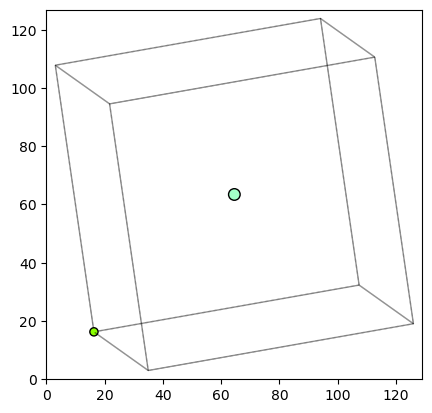

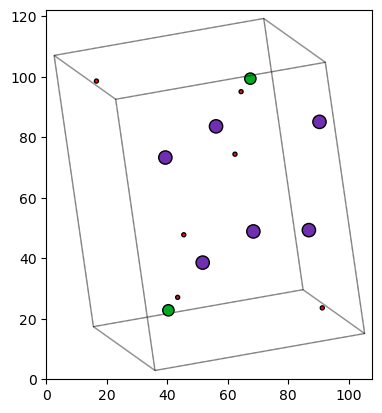

In [8]:
#list of keys
test_graphs = test_graphs_mp
list_of_keys = list(test_graphs.keys())
for key in tqdm(list_of_keys):
    test_crystal = test_graphs[key]
    frac_coords, atom_types, lengths, angles, edge_indices, to_jimages, num_atoms = test_crystal
    frac_coords_tensor = torch.tensor(frac_coords)
    atom_types_tensor = torch.tensor(atom_types)
    lengths_tensor = torch.tensor(lengths)
    angles_tensor = torch.tensor(angles)
    edge_indices_tensor = torch.tensor(edge_indices)
    to_jimages_tensor = torch.tensor(to_jimages)
    num_atoms_tensor = torch.tensor(num_atoms)
    crystal_dict = {'frac_coords': frac_coords_tensor,
                        'atom_types': atom_types_tensor,
                        'lengths': lengths_tensor,
                        'angles': angles_tensor}

    crystal_object = Crystal(crystal_dict)
    if not crystal_object.valid:
        print("crystal {} is not valid".format(key))
        print(atom_types)
        print(num_atoms)
        save_directory = '/home/gridsan/tmackey/cdvae/data/mp_20_dm/invalid_crystals/'
        save_crystal_image_ase(frac_coords, atom_types, lengths, angles, filename=save_directory + f'{key}.png')


In [ ]:
test_crystal = test_graphs[key]
frac_coords, atom_types, lengths, angles, edge_indices, to_jimages, num_atoms = test_crystal
frac_coords_tensor = torch.tensor(frac_coords)
atom_types_tensor = torch.tensor(atom_types)
lengths_tensor = torch.tensor(lengths)
angles_tensor = torch.tensor(angles)
edge_indices_tensor = torch.tensor(edge_indices)
to_jimages_tensor = torch.tensor(to_jimages)
num_atoms_tensor = torch.tensor(num_atoms)
crystal_dict = {'frac_coords': frac_coords_tensor,
                    'atom_types': atom_types_tensor,
                    'lengths': lengths_tensor,
                    'angles': angles_tensor}
save_crystal_image_ase(frac_coords, atom_types, lengths, angles, filename=save_directory + f'{key}.png')

It seems like neither the xrd patterns nor the compounds are at fault. It's possible that the model is just not learning from the data. But why is this the case? To understand better, it might be worth taking a look at some of the deepmind compounds in vesta. To do this, we'll need to write some cif files from the cif column of the data.

In [1]:
import pandas as pd
import numpy as np

In [2]:
train_df_dm = pd.read_csv('/home/gridsan/tmackey/cdvae/data/mp_20_dm/train.csv')

In [3]:
train_df_dm

,composition,cif,xrd,xrd_peak_locations,xrd_peak_intensities,atomic_numbers,disc_sim_xrd,material_id,formation_energy_per_atom
0,by_composition/Ho20Pd9Ru3.CIF,# generated using pymatgen\ndata_Ho20(Pd3Ru)3\...,DiffractionPattern\n$2\Theta$: [ 8.00264788 11...,"[8.002647875267968, 11.326690887819138, 14.028...","[0.05592414281200831, 2.0637376808172534, 0.09...","[67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 6...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_0,0.0
1,by_composition/Ac2C2Cl2.CIF,# generated using pymatgen\ndata_AcCCl\n_symme...,DiffractionPattern\n$2\Theta$: [ 8.61162617 17...,"[8.611626171731944, 17.272374240466434, 23.033...","[100.0, 15.279471052604062, 5.046706259323383,...","[89, 89, 6, 6, 17, 17]",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_1,0.0
2,by_composition/Ag2Ir2Nd2O14Rh2.CIF,# generated using pymatgen\ndata_NdAgIrRhO7\n_...,DiffractionPattern\n$2\Theta$: [14.66406463 15...,"[14.664064626720043, 15.06907520666032, 17.305...","[0.030704415637085477, 4.725837224779201, 7.56...","[60, 60, 47, 47, 77, 77, 45, 45, 8, 8, 8, 8, 8...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_2,0.0
3,by_composition/Ga6Pd5Rh7Ti6.CIF,# generated using pymatgen\ndata_Ti6Ga6Pd5Rh7\...,DiffractionPattern\n$2\Theta$: [ 7.34295344 12...,"[7.3429534404570225, 12.271483838595135, 14.31...","[0.0015028916430882646, 0.00731082040043184, 0...","[22, 22, 22, 22, 22, 22, 31, 31, 31, 31, 31, 3...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_3,0.0
4,by_composition/Ag9Ca6O18Sb3.CIF,# generated using pymatgen\ndata_Ca2Ag3SbO6\n_...,DiffractionPattern\n$2\Theta$: [14.04812142 17...,"[14.048121418932963, 17.187764975999368, 17.82...","[3.785248536553743, 11.168095544523403, 12.680...","[20, 20, 20, 20, 20, 20, 47, 47, 47, 47, 47, 4...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_4,0.0
...,...,...,...,...,...,...,...,...,...
226318,by_composition/In1Pb5S2Y10.CIF,# generated using pymatgen\ndata_Y10InPb5S2\n_...,DiffractionPattern\n$2\Theta$: [11.24472906 11...,"[11.244729056625514, 11.260792722605984, 13.14...","[13.688873013068992, 5.527131248971, 1.2248076...","[39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 49, 8...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_226328,0.0
226319,by_composition/B2Br15Sm10.CIF,# generated using pymatgen\ndata_Sm10B2Br15\n_...,DiffractionPattern\n$2\Theta$: [ 9.10028706 9...,"[9.100287058018477, 9.60424101764612, 10.93814...","[33.43070122338162, 4.675715916006975, 26.9309...","[62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 5, 5,...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_226329,0.0
226320,by_composition/Cu2La4Rb2Se10Sr2.CIF,# generated using pymatgen\ndata_RbSrLa2CuSe5\...,DiffractionPattern\n$2\Theta$: [ 9.40034078 11...,"[9.400340782476523, 11.886801834209539, 12.787...","[0.8612705412608644, 44.96197158764954, 12.731...","[37, 37, 38, 38, 57, 57, 57, 57, 29, 29, 34, 3...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_226330,0.0
226321,by_composition/C4Eu1Tc4.CIF,# generated using pymatgen\ndata_Eu(TcC)4\n_sy...,DiffractionPattern\n$2\Theta$: [15.24132039 15...,"[15.241320392018896, 15.249211588660454, 21.62...","[4.0302770457298545, 3.9919974511942824, 0.945...","[63, 43, 43, 43, 43, 6, 6, 6, 6]",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_226331,0.0


In [4]:
#remove "by_composition" from the entries in the composition column
train_df_dm['composition'] = train_df_dm['composition'].apply(lambda x: x.replace("by_composition/", ""))

In [5]:
train_df_dm

,composition,cif,xrd,xrd_peak_locations,xrd_peak_intensities,atomic_numbers,disc_sim_xrd,material_id,formation_energy_per_atom
0,Ho20Pd9Ru3.CIF,# generated using pymatgen\ndata_Ho20(Pd3Ru)3\...,DiffractionPattern\n$2\Theta$: [ 8.00264788 11...,"[8.002647875267968, 11.326690887819138, 14.028...","[0.05592414281200831, 2.0637376808172534, 0.09...","[67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 6...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_0,0.0
1,Ac2C2Cl2.CIF,# generated using pymatgen\ndata_AcCCl\n_symme...,DiffractionPattern\n$2\Theta$: [ 8.61162617 17...,"[8.611626171731944, 17.272374240466434, 23.033...","[100.0, 15.279471052604062, 5.046706259323383,...","[89, 89, 6, 6, 17, 17]",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_1,0.0
2,Ag2Ir2Nd2O14Rh2.CIF,# generated using pymatgen\ndata_NdAgIrRhO7\n_...,DiffractionPattern\n$2\Theta$: [14.66406463 15...,"[14.664064626720043, 15.06907520666032, 17.305...","[0.030704415637085477, 4.725837224779201, 7.56...","[60, 60, 47, 47, 77, 77, 45, 45, 8, 8, 8, 8, 8...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_2,0.0
3,Ga6Pd5Rh7Ti6.CIF,# generated using pymatgen\ndata_Ti6Ga6Pd5Rh7\...,DiffractionPattern\n$2\Theta$: [ 7.34295344 12...,"[7.3429534404570225, 12.271483838595135, 14.31...","[0.0015028916430882646, 0.00731082040043184, 0...","[22, 22, 22, 22, 22, 22, 31, 31, 31, 31, 31, 3...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_3,0.0
4,Ag9Ca6O18Sb3.CIF,# generated using pymatgen\ndata_Ca2Ag3SbO6\n_...,DiffractionPattern\n$2\Theta$: [14.04812142 17...,"[14.048121418932963, 17.187764975999368, 17.82...","[3.785248536553743, 11.168095544523403, 12.680...","[20, 20, 20, 20, 20, 20, 47, 47, 47, 47, 47, 4...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_4,0.0
...,...,...,...,...,...,...,...,...,...
226318,In1Pb5S2Y10.CIF,# generated using pymatgen\ndata_Y10InPb5S2\n_...,DiffractionPattern\n$2\Theta$: [11.24472906 11...,"[11.244729056625514, 11.260792722605984, 13.14...","[13.688873013068992, 5.527131248971, 1.2248076...","[39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 49, 8...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_226328,0.0
226319,B2Br15Sm10.CIF,# generated using pymatgen\ndata_Sm10B2Br15\n_...,DiffractionPattern\n$2\Theta$: [ 9.10028706 9...,"[9.100287058018477, 9.60424101764612, 10.93814...","[33.43070122338162, 4.675715916006975, 26.9309...","[62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 5, 5,...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_226329,0.0
226320,Cu2La4Rb2Se10Sr2.CIF,# generated using pymatgen\ndata_RbSrLa2CuSe5\...,DiffractionPattern\n$2\Theta$: [ 9.40034078 11...,"[9.400340782476523, 11.886801834209539, 12.787...","[0.8612705412608644, 44.96197158764954, 12.731...","[37, 37, 38, 38, 57, 57, 57, 57, 29, 29, 34, 3...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_226330,0.0
226321,C4Eu1Tc4.CIF,# generated using pymatgen\ndata_Eu(TcC)4\n_sy...,DiffractionPattern\n$2\Theta$: [15.24132039 15...,"[15.241320392018896, 15.249211588660454, 21.62...","[4.0302770457298545, 3.9919974511942824, 0.945...","[63, 43, 43, 43, 43, 6, 6, 6, 6]",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,train_not_true_mat_id_226331,0.0


In [7]:
import ast 
#apply ast.literal_eval to the atomic_numbers column
train_df_dm['atomic_numbers'] = train_df_dm['atomic_numbers'].apply(lambda x: ast.literal_eval(x))

In [8]:
atomic_numbers = train_df_dm['atomic_numbers'].tolist()
num_atoms = [len(x) for x in atomic_numbers]

(0.0, 5.0)

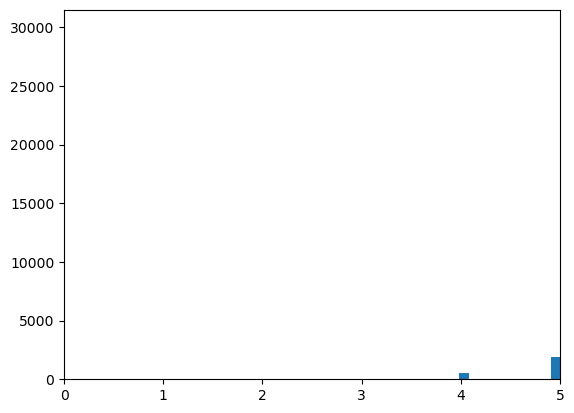

In [17]:
import matplotlib.pyplot as plt

plt.hist(num_atoms, bins=1000)
#set x-lim to 0, 10
plt.xlim(0, 5)

(0.0, 10.0)

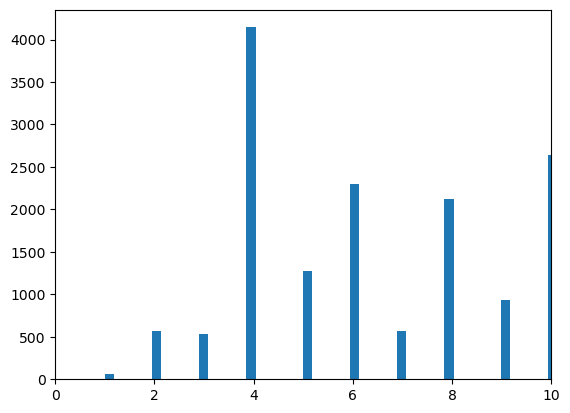

In [12]:
train_df_mp = pd.read_csv('/home/gridsan/tmackey/cdvae/data/mp_20/train.csv')
#apply ast.literal_eval to the atomic_numbers column
train_df_mp['atomic_numbers'] = train_df_mp['atomic_numbers'].apply(lambda x: ast.literal_eval(x))

atomic_numbers_mp = train_df_mp['atomic_numbers'].tolist()
num_atoms_mp = [len(x) for x in atomic_numbers_mp]

(0.0, 10.0)

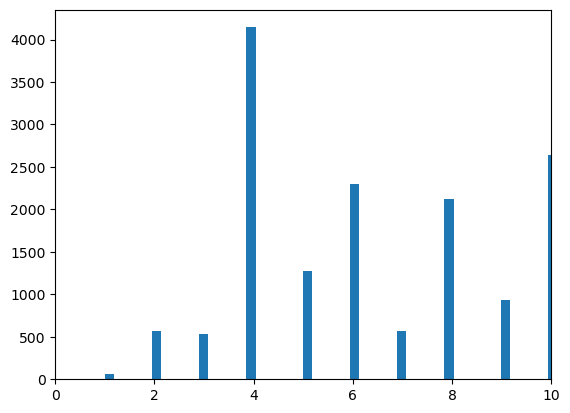

In [13]:
plt.hist(num_atoms_mp, bins=100)
#set x-lim to 0, 10
plt.xlim(0, 10)

In [6]:
#write the first 1000 entries in the 'cif' column to files named with the entry in the composition column
import os
import sys
from tqdm import tqdm

data_dir = "/home/gridsan/tmackey/materials_discovery/data/actually_full_gnome_data/cif_files/"

for index, row in tqdm(train_df_dm.iterrows()):
    if index < 1000:
        composition = row['composition']
        cif = row['cif']
        with open(data_dir + composition + ".cif", "w") as file:
            file.write(cif)

226323it [00:24, 9270.22it/s] 
